# EDA

В датасете — дневное число визитов в рестораны Японии за период с **1 января 2016 года по 22 апреля 2017 года**.

Перед построением модели посмотрим на данные: 

0. Загрузка и обзор
1. Гости и выбросы
2. Динамика во времени
3. Недельная сезонность
4. Годовая сезонность
5. Праздники
6. Обработка пропусков
7. Итоги и выводы для модели


## 0. Загрузка и обзор

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
sys.path.append("..")
from src.data import load_data

In [9]:

DATA_DIR = Path("../data/raw")
data = load_data(DATA_DIR)


In [59]:
data.head()

,restaurant_id,date,guests,is_holiday,genre,area,dow,year,cal_month,month,robust_z,is_outlier,guests_ratio
0,air_00a91d42b08b08d9,2016-07-01,35,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,4,2016,7,7,-0.051885,False,1.346154
1,air_00a91d42b08b08d9,2016-07-02,9,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,5,2016,7,7,-0.245273,False,0.346154
2,air_00a91d42b08b08d9,2016-07-04,20,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,0,2016,7,7,0.168625,False,0.769231
3,air_00a91d42b08b08d9,2016-07-05,25,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,1,2016,7,7,0.061318,False,0.961538
4,air_00a91d42b08b08d9,2016-07-06,29,0,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami,2,2016,7,7,0.112417,False,1.115385


In [10]:
DARK, BLUE, MID, LIGHT, PALE = "#0B3C5D", "#1D70B8", "#4A90D9", "#A8D0F0", "#DCEBFA"
RED, GRAY = "#D64545", "#6B7A8C"

BLUE_CMAP = sns.light_palette(BLUE, as_cmap=True)
DOW = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": DARK,
    "axes.labelsize": 11,
    "axes.edgecolor": GRAY,
    "grid.color": "#E3ECF5",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(
        color=[BLUE, DARK, MID, LIGHT, RED]
    ),
})

In [19]:
data["dow"] = data["date"].dt.dayofweek
data["year"] = data["date"].dt.year
data["cal_month"] = data["date"].dt.month

# первая и последняя запись каждого рестррана, дни, пропуски в ряду
profile = data.groupby("restaurant_id").agg(
      first=("date", "min"),
      last=("date", "max"),
      days=("date", "nunique"),
      median_guests=("guests", "median"),
      genre=("genre", "first"),
)
profile["span"] = (profile["last"] - profile["first"]).dt.days + 1
profile["gaps"] = profile["span"] - profile["days"]

total_days = (data["date"].max() - data["date"].min()).days + 1
print(f"Строк: {len(data):,}")
print(f"Ресторанов: {data['restaurant_id'].nunique()}")
print(f"Период: {data['date'].min().date()} — {data['date'].max().date()} ({total_days} дней)")
print(f"Дней с записью на ресторан: медиана {profile['days'].median():.0f} "
      f"(min {profile['days'].min()}, max {profile['days'].max()})")
print(f"Есть пропуски внутри истории: {(profile['gaps'] > 0).mean():.0%}")
print(f"Пропусков внутри истории на ресторан: среднее {profile['gaps'].mean():.0f}, "
      f"медиана {profile['gaps'].median():.0f} дней")
print(f"Ресторанов, начавших запись позже 1 марта 2016: "
      f"{(profile['first'] > '2016-03-01').mean():.0%}")

Строк: 252,108
Ресторанов: 829
Период: 2016-01-01 — 2017-04-22 (478 дней)
Дней с записью на ресторан: медиана 284 (min 20, max 477)
Есть пропуски внутри истории: 99%
Пропусков внутри истории на ресторан: среднее 53, медиана 47 дней
Ресторанов, начавших запись позже 1 марта 2016: 63%


У ресторанов разная длина истории, а внутри некоторых историй есть пропуски.

Это важно для прогноза: отсутствие строки не означает автоматически нулевое количество гостей. Перед построением лагов нужно восстановить календарь каждого ресторана и отдельно разобраться с причинами пропусков.

## 1. Целевая переменная и выбросы
сколько гостей обычно приходит за день и насколько рестораны отличаются друг от друга 

(ошибка прогноза в 5 гостей имеет разный смысл для ресторанов разных размеров)


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
sys.path.append("..")
from src.data import load_data

count    252108.0
mean         21.0
std          16.8
min           1.0
5%            3.0
25%           9.0
50%          17.0
75%          29.0
95%          52.0
99%          73.0
max         877.0

Асимметрия: 3.31
Ресторанов с медианой < 10 гостей: 21%
Ресторанов с медианой ≥ 15 гостей: 60%


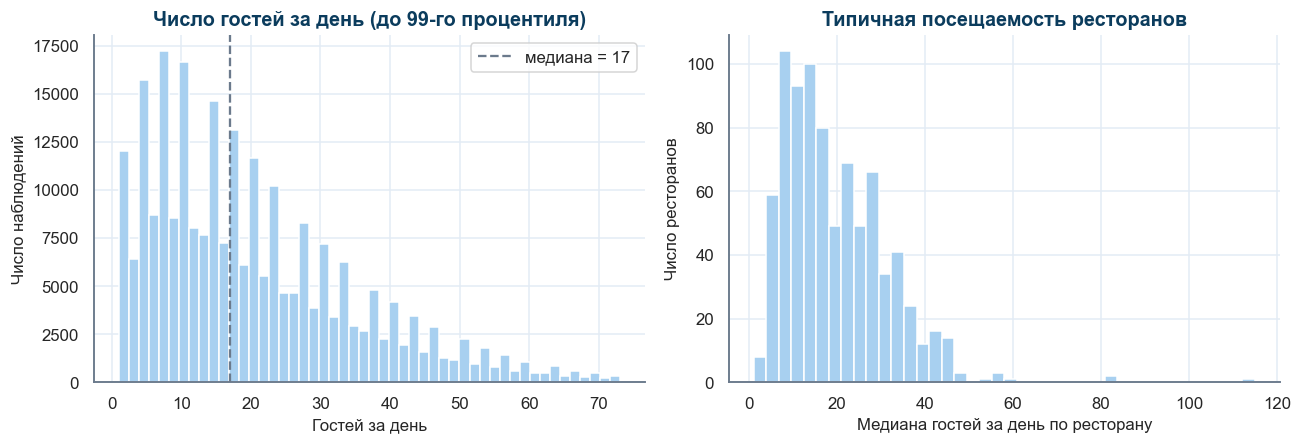

In [33]:
print(data["guests"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1).to_string())
print(f"\nАсимметрия: {data['guests'].skew():.2f}")
print(f"Ресторанов с медианой < 10 гостей: {(profile['median_guests'] < 10).mean():.0%}")
print(f"Ресторанов с медианой ≥ 15 гостей: {(profile['median_guests'] >= 15).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

upper = data["guests"].quantile(0.99)
axes[0].hist(data.loc[data["guests"] <= upper, "guests"], bins=50, color=LIGHT, edgecolor="white")
axes[0].axvline(data["guests"].median(), color=GRAY, ls="--", label=f"медиана = {data['guests'].median():.0f}")
axes[0].set(title="Число гостей за день (до 99-го процентиля)", xlabel="Гостей за день", ylabel="Число наблюдений")
axes[0].legend()

axes[1].hist(profile["median_guests"], bins=40, color=LIGHT, edgecolor="white")
axes[1].set(title="Типичная посещаемость ресторанов", xlabel="Медиана гостей за день по ресторану", ylabel="Число ресторанов")

plt.tight_layout()
plt.show()

Большинство ресторанов работает с относительно небольшим потоком гостей, 
но между ресторанами есть заметная разница в типичной загрузке (распределение гостей смещено вправо). 

Для большой части ресторанов типичная посещаемость находится примерно в диапазоне 11–27 гостей в день. Небольшая абсолютная ошибка может быть заметной для небольших ресторанов соответственно.

Для бизнеса удобнее всего интерпретировать ошибку в количестве гостей. **MAE** показывает, на сколько гостей в среднем ошибается прогноз, это напрямую связано с вопросом: насколько прогноз отличается от фактической
загрузки ресторана.

**MAPE** показывает ошибку относительно фактической посещаемости и помогает
сравнивать рестораны разного размера (как в нашем даттсете), поэтому дальше будем смотреть на обе метрики.

## Выбросы

In [39]:
upper = data["guests"].quantile(0.99)

print(f"99-й процентиль: {upper:.0f} гостей")
print(
    f"Наблюдений выше 99-го процентиля: "
    f"{(data['guests'] > upper).mean():.2%}"
)


99-й процентиль: 73 гостей
Наблюдений выше 99-го процентиля: 0.96%


99-й процентиль: 3.5x от медианы
Наблюдений выше него: 1.00%


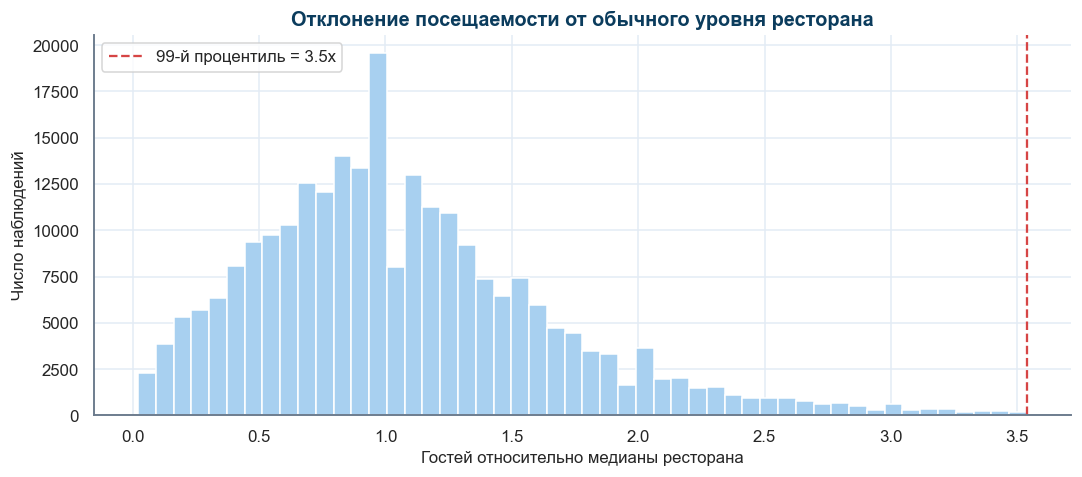

In [56]:
restaurant_median = data.groupby("restaurant_id")["guests"].transform("median")
guests_ratio = data["guests"] / restaurant_median
upper = guests_ratio.quantile(0.99)

print(f"99-й процентиль: {upper:.1f}x от медианы")
print(f"Наблюдений выше него: {(guests_ratio > upper).mean():.2%}")

plt.figure(figsize=(10, 4.5))
plt.hist(data.loc[data["guests_ratio"] <= upper, "guests_ratio"], bins=50, color=LIGHT, edgecolor="white")
plt.axvline(upper, color=RED, ls="--", label=f"99-й процентиль = {upper:.1f}x")
plt.title("Отклонение посещаемости от обычного уровня ресторана")
plt.xlabel("Гостей относительно медианы ресторана")
plt.ylabel("Число наблюдений")
plt.legend()
plt.tight_layout()
plt.show()

В данных есть отдельные дни с аномально высокой посещаемостью относительно обычного уровня конкретного ресторана. Верхний 1% наблюдений превышает медианный уровень ресторана более чем в 3.5 раза. Такие значения не будем автоматически удалять, тк они могут отражать реальные пики спроса, например праздники или другие особенности конкретного дня.

## 2. Динамика во времени

Смотрим на посещаемость по неделям: 

сколько всего гостей приходит, растёт ли поток на самом деле, или дело просто в том, что в систему подключается всё больше ресторанов

In [51]:
daily_mean = (
    data.groupby(["date", "restaurant_id"])["guests"]
    .mean()
    .groupby("date")
    .mean()
)

weekly_guests = daily_mean.resample("W-SUN").mean()

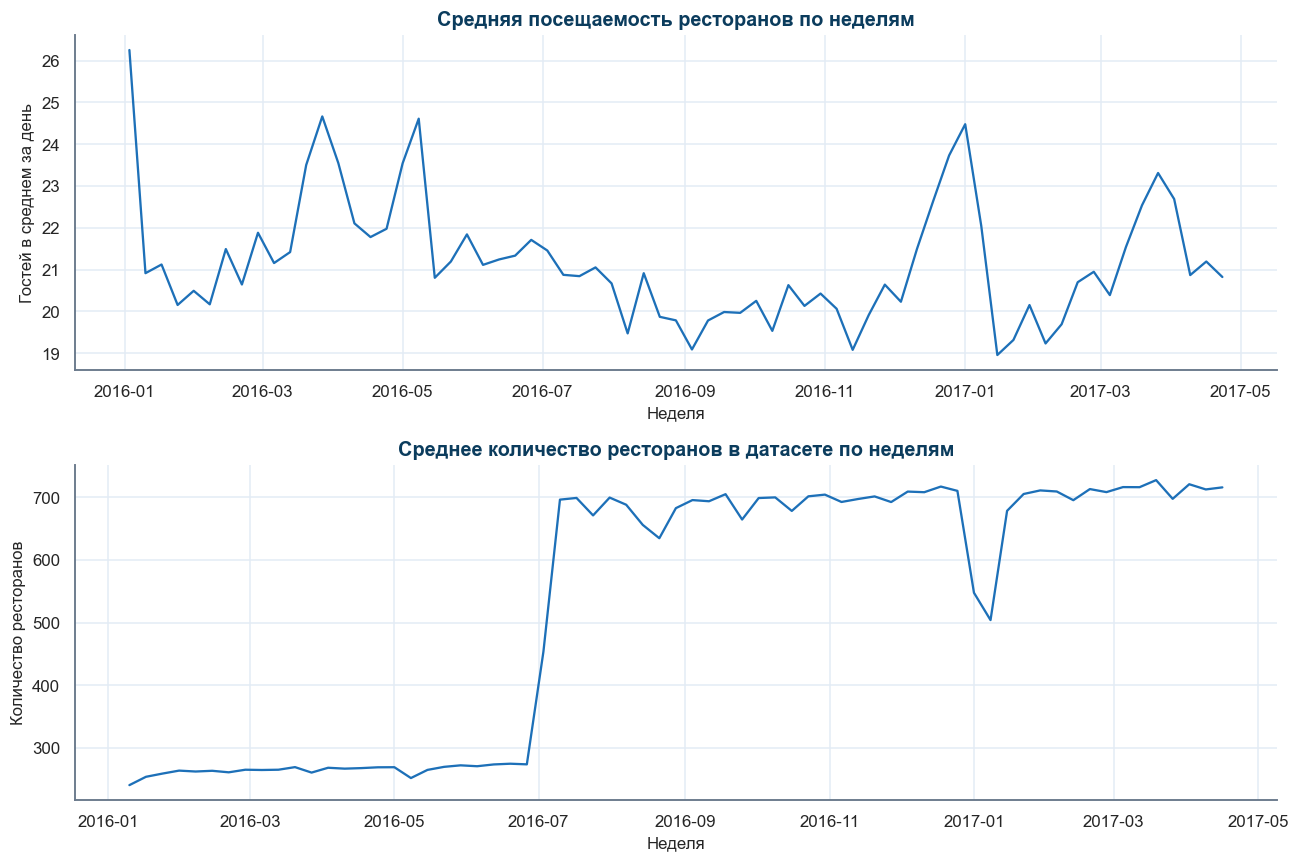

In [55]:
restaurants_per_day = data.groupby("date")["restaurant_id"].nunique()
weekly_restaurants = restaurants_per_day.resample("W-SUN").mean().iloc[1:-1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(weekly_guests.index, weekly_guests.values, color=BLUE)
axes[0].set_title("Средняя посещаемость ресторанов по неделям")
axes[0].set_xlabel("Неделя")
axes[0].set_ylabel("Гостей в среднем за день")

axes[1].plot(weekly_restaurants.index, weekly_restaurants.values, color=BLUE)
axes[1].set_title("Среднее количество ресторанов в датасете по неделям")
axes[1].set_xlabel("Неделя")
axes[1].set_ylabel("Количество ресторанов")

plt.tight_layout()
plt.show()

Средняя посещаемость ресторанов заметно меняется во времени, при этом количество ресторанов в датасете тоже резко увеличивается примерно с июля 2016 года — примерно с 250 до 700, поэтому сравнение уровня посещаемости между началом и второй половиной периода нужно интерпретировать осторожно

## 3. Недельная сезонность

Проверим, есть ли у ресторанов устойчивый ритм посещаемости в зависимости от дня недели.

Чтобы рестораны с большим потоком гостей не влияли на результат сильнее остальных, сначала посчитаем среднюю посещаемость для каждого ресторана отдельно, а затем усредним полученные значения между ресторанами.

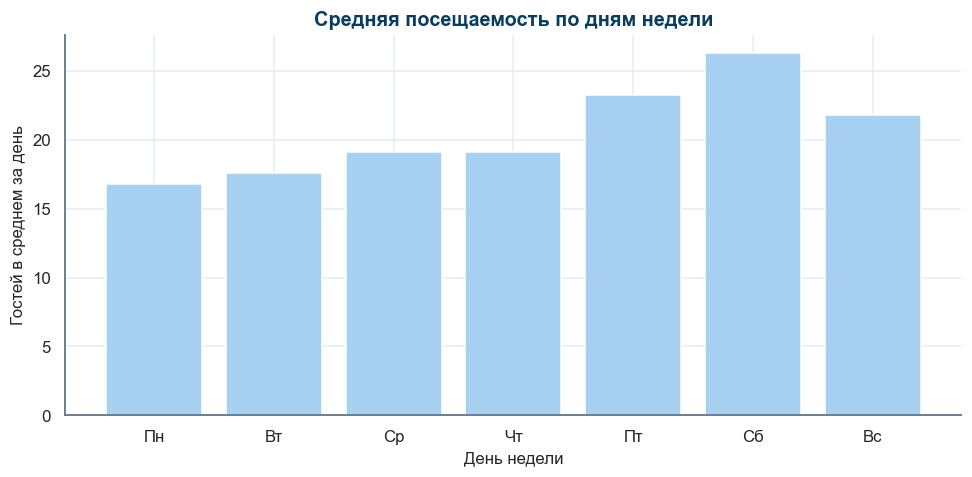

In [57]:
dow_mean = data.groupby(["restaurant_id", "dow"])["guests"].mean().groupby("dow").mean()

plt.figure(figsize=(9, 4.5))
plt.bar(DOW, dow_mean.values, color=LIGHT, edgecolor="white")
plt.title("Средняя посещаемость по дням недели")
plt.xlabel("День недели")
plt.ylabel("Гостей в среднем за день")
plt.tight_layout()
plt.show()

Посещаемость заметно зависит от дня недели: в будни она постепенно растёт к пятнице, максимальный уровень посещаемости наблюдается в субботу. Поэтому день недели будет важным календарным признаком, лаги на 7, 14 и 21 день -- повторяющийся недельный ритм

## 4. Годовая сезонность

Данных чуть больше 15 месяцев: январь–апрель мы видим дважды (2016 и 2017), остальные месяцы — по одному разу. Чтобы состав ресторанов не искажал картину, берём только рестораны с полной историей (от января 2016)

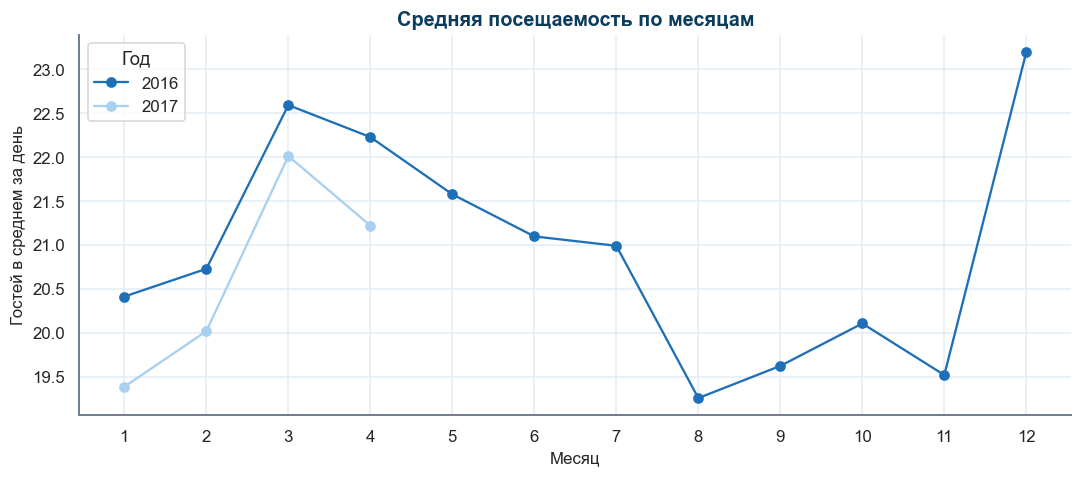

In [58]:
monthly_mean = data.groupby(["restaurant_id", "year", "month"])["guests"].mean().groupby(["year", "month"]).mean().unstack("year")

monthly_mean.plot(figsize=(10, 4.5), marker="o", color=[BLUE, LIGHT])
plt.title("Средняя посещаемость по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Гостей в среднем за день")
plt.xticks(range(1, 13))
plt.legend(title="Год")
plt.tight_layout()
plt.show()

В данных наблюдаются различия в посещаемости между месяцами, но полного годового цикла недостаточно для уверенного вывода о стабильной годовой сезонности. Месяц добавим в модель как дополнительный календарный признак, но не будем считать его таким же сильным, как день недели

## 5. Праздники

Проверим, отличается ли посещаемость в праздничные дни от обычных дней того же дня недели.

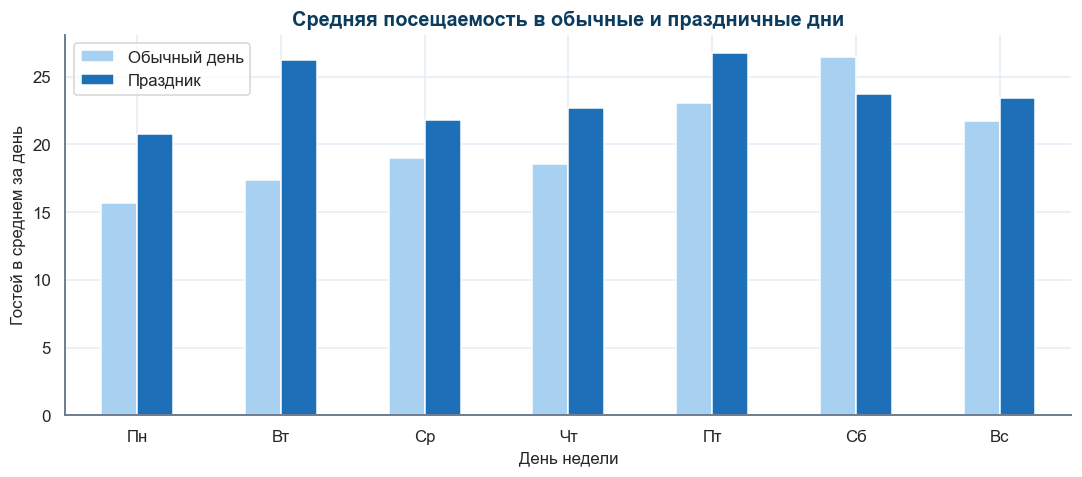

In [81]:
holiday_mean = data.groupby(["restaurant_id", "dow", "is_holiday"])["guests"].mean().groupby(["dow", "is_holiday"]).mean().unstack()

holiday_mean.plot(kind="bar", figsize=(10, 4.5), color=[LIGHT, BLUE], edgecolor="white")
plt.title("Средняя посещаемость в обычные и праздничные дни")
plt.xlabel("День недели")
plt.ylabel("Гостей в среднем за день")
plt.xticks(range(7), DOW, rotation=0)
plt.legend(["Обычный день", "Праздник"])
plt.tight_layout()
plt.show()

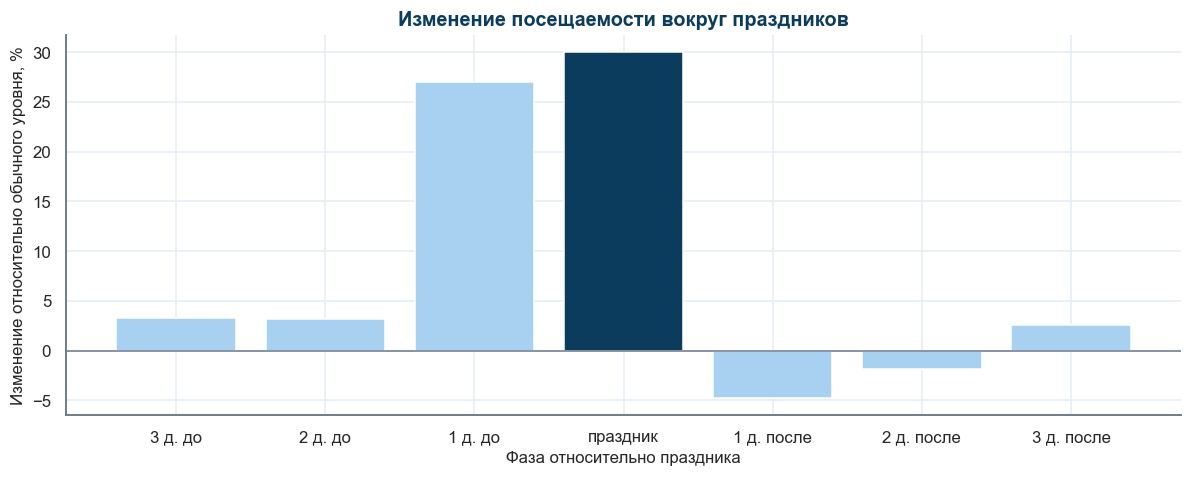

In [64]:
cal = data[["date", "is_holiday"]].drop_duplicates("date").set_index("date").sort_index().asfreq("D")
h = cal["is_holiday"].fillna(0)

cal["phase"] = "обычный"
cal.loc[h == 1, "phase"] = "праздник"

for k in (1, 2, 3):
    cal.loc[(h.shift(k) == 1) & (cal["phase"] == "обычный"), "phase"] = f"{k} д. после"
    cal.loc[(h.shift(-k) == 1) & (cal["phase"] == "обычный"), "phase"] = f"{k} д. до"

PHASES = ["3 д. до", "2 д. до", "1 д. до", "праздник", "1 д. после", "2 д. после", "3 д. после"]

hol = data[["restaurant_id", "date", "dow", "guests"]].copy()
hol["phase"] = hol["date"].map(cal["phase"])

baseline = hol[hol["phase"] == "обычный"].groupby(["restaurant_id", "dow"])["guests"].mean().rename("baseline").reset_index()
hol = hol.merge(baseline, on=["restaurant_id", "dow"], how="left")
hol["effect"] = (hol["guests"] / hol["baseline"] - 1) * 100
effect = hol[hol["phase"].isin(PHASES)].groupby(["phase", "restaurant_id"])["effect"].mean().groupby("phase").mean().reindex(PHASES)

plt.figure(figsize=(11, 4.5))
plt.bar(PHASES, effect.values, color=[LIGHT, LIGHT, LIGHT, DARK, LIGHT, LIGHT, LIGHT], edgecolor="white")
plt.axhline(0, color=GRAY, lw=1)
plt.title("Изменение посещаемости вокруг праздников")
plt.xlabel("Фаза относительно праздника")
plt.ylabel("Изменение относительно обычного уровня, %")
plt.tight_layout()
plt.show()

В большинстве дней недели посещаемость в праздники выше, чем в обычные дни. Особенно заметна разница в понедельник, вторник и четверг, тогда как в субботу праздничные дни, наоборот, немного менее посещаемы. Признак праздника стоит добавить в модель отдельно от дня недели

## 6. Обработка пропусков

In [71]:
actual_days = data.groupby("restaurant_id")["date"].nunique()
missing_days = (profile["span"] - actual_days).sum()

print(f"Пропущенных дней внутри историй: {missing_days:,}")
print(f"Доля пропусков: {missing_days / profile['span'].sum():.2%}")

Пропущенных дней внутри историй: 44,171
Доля пропусков: 14.91%


Внутри историй ресторанов отсутствуют **44 171 дней (~15% от ожидаемых наблюдений)**. Эти дни просто отсутствуют в исходной таблице — это не нулевые значения.

Отсутствующая дата может означать закрытие ресторана, регулярный выходной или отсутствие данных. Такие дни нельзя автоматически считать нулевым количеством гостей.

In [73]:
dates = pd.date_range(data["date"].min(), data["date"].max(), freq="D")
calendar = pd.MultiIndex.from_product([data["restaurant_id"].unique(), dates], names=["restaurant_id", "date"]).to_frame(index=False)
calendar = calendar.merge(data[["restaurant_id", "date"]], on=["restaurant_id", "date"], how="left", indicator=True)
calendar = calendar.merge(profile[["first", "last"]], left_on="restaurant_id", right_index=True)
calendar = calendar[(calendar["date"] >= calendar["first"]) & (calendar["date"] <= calendar["last"])]

calendar["missing"] = calendar["_merge"] == "left_only"
calendar["dow"] = calendar["date"].dt.dayofweek

In [ ]:
dates = pd.date_range(data["date"].min(), data["date"].max(), freq="D")

calendar = pd.MultiIndex.from_product(
    [profile.index, dates],
    names=["restaurant_id", "date"]
).to_frame(index=False)

calendar = calendar.merge(
    profile[["first", "last"]],
    left_on="restaurant_id",
    right_index=True
)

calendar["active"] = (
    (calendar["date"] >= calendar["first"]) &
    (calendar["date"] <= calendar["last"])
)

calendar["observed"] = calendar.set_index(["restaurant_id", "date"]).index.isin(
    data.set_index(["restaurant_id", "date"]).index
)

calendar["missing"] = calendar["active"] & ~calendar["observed"]
calendar["dow"] = calendar["date"].dt.dayofweek

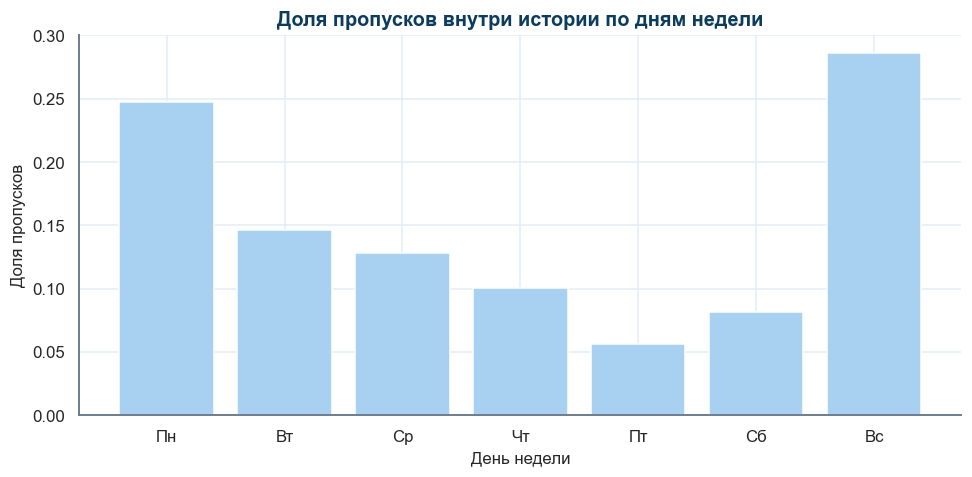

In [74]:
missing_by_dow = calendar.groupby("dow")["missing"].mean()

plt.figure(figsize=(9, 4.5))
plt.bar(DOW, missing_by_dow.values, color=LIGHT, edgecolor="white")
plt.title("Доля пропусков внутри истории по дням недели")
plt.xlabel("День недели")
plt.ylabel("Доля пропусков")
plt.tight_layout()
plt.show()

Больше всего пропусков приходится на воскресенье и понедельник, меньше всего — на пятницу и субботу

Проверим, связаны ли такие пропуски с праздниками, регулярными выходными
ресторанов или длинными периодами отсутствия данных.

In [80]:
calendar["active"] = (calendar["date"] >= calendar["first"]) & (calendar["date"] <= calendar["last"])
active = calendar[calendar["active"]]

regular_off = active.groupby(["restaurant_id", "dow"])["missing"].mean() >= 0.8

print(f"Ресторанов с регулярным выходным: {regular_off.groupby(level=0).any().mean():.0%}")
print("\nРегулярные выходные по дням недели:")
print(regular_off.groupby(level="dow").sum().rename(index=dict(enumerate(DOW))).to_string())

Ресторанов с регулярным выходным: 34%

Регулярные выходные по дням недели:
dow
Пн     89
Вт     30
Ср     31
Чт     18
Пт      6
Сб     13
Вс    142


У части ресторанов пропуски регулярно приходятся на одни и те же дни недели.
Такие дни будем рассматривать как возможные регулярные выходные и учитывать это при восстановлении календаря в `cleaning.py`.

Остальные пропуски нельзя автоматически считать закрытием ресторана, для них оставим отдельную категорию и не будем подменять пропуски нулевой посещаемостью без доп основания

In [84]:
holiday_dates = data.loc[data["is_holiday"] == 1, "date"].unique()
calendar["is_holiday"] = calendar["date"].isin(holiday_dates)
holiday_missing = calendar[calendar["active"]].groupby("is_holiday")["missing"].mean()
print("\nДоля пропусков:")
print(holiday_missing.rename({False: "Обычные дни", True: "Праздники"}).round(2).to_string())


Доля пропусков:
is_holiday
Обычные дни    0.14
Праздники      0.33


В праздничные дни доля пропусков заметно выше, чем в обычные: 33% против 14%. Это говорит о том, что часть пропусков может быть связана с закрытием ресторанов в праздники, но считать все такие пропуски закрытиями нельзя. Поэтому при восстановлении календаря будем учитывать праздники как один из признаков, а остальные пропуски разберём отдельно

Далее посмотрим на длинные пропуски (гипотеза, что длинные пропуски — это временные закрытия или сбои). Сначала посмотрим распределение длин пропусков и выберем порог (через квантили) что считаем "длинным" пропуском

In [91]:
runs.value_counts().sort_index().head(10)

1     20435
2      4792
3      1067
4       508
5       300
6       235
7        96
8        61
9        30
10       25
Name: count, dtype: int64

In [93]:
print(runs.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))

count    27691.0
mean         1.6
std          3.6
min          1.0
50%          1.0
75%          2.0
90%          2.0
95%          4.0
99%          7.0
max        256.0
dtype: float64


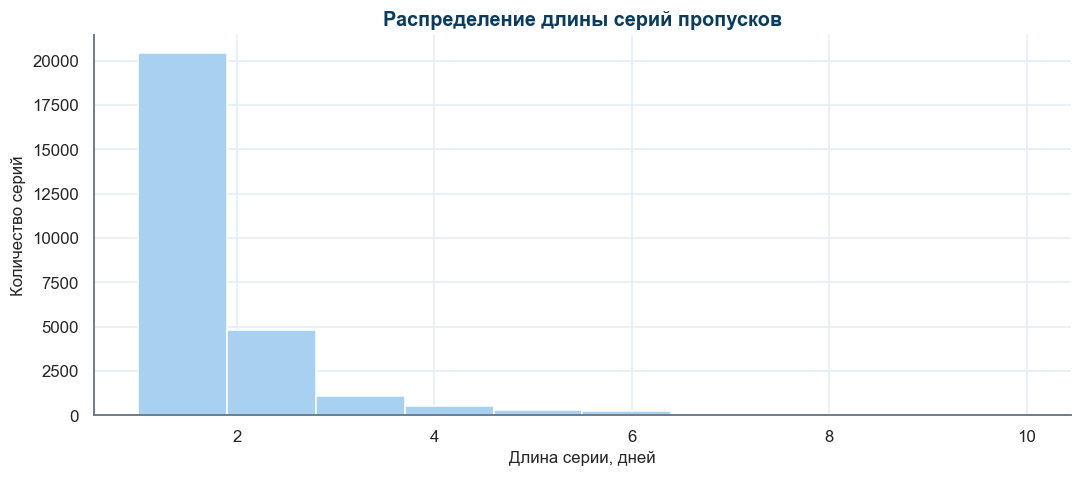

In [94]:
plt.figure(figsize=(10, 4.5))
plt.hist(runs[runs <= 10], bins=10, color=LIGHT, edgecolor="white")
plt.title("Распределение длины серий пропусков")
plt.xlabel("Длина серии, дней")
plt.ylabel("Количество серий")
plt.tight_layout()
plt.show()

In [85]:
g = calendar.sort_values(["restaurant_id", "date"])
run_id = (~g["missing"]).groupby(g["restaurant_id"]).cumsum()
runs = g[g["missing"]].groupby(["restaurant_id", run_id.loc[g["missing"].index]]).size()

print(f"Серий пропусков: {len(runs):,}")
print(f"Одиночных пропусков: {(runs == 1).mean():.0%}")
print(f"Серий от 14 дней: {(runs >= 14).mean():.1%}")

Серий пропусков: 27,691
Одиночных пропусков: 74%
Серий от 14 дней: 0.3%


Большинство пропусков приходится на короткие серии: 75% серий имеют длину не более двух дней. Поэтому в дальнейшей обработке будем считать серии от 3 дней длительными и рассматривать их отдельно. При этом сама длительность не означает, что ресторан был закрыт

## Обработка пропусков

После наших проверок имеем три исхода:

1. Регулярный выходной ресторана → пропуск можно считать закрытием → guests = 0.

2. Праздничный день → пропуск может быть связан с закрытием, но это не гарантировано → учитываем как отдельный признак, а не автоматически заменяем на 0.

3. Остальные пропуски → оставляем неизвестными и не используем как целевые значения при обучении

Серии от 3 дней считаем длительными и рассматриваем отдельно.

## 7. Итоги

Посещаемость ресторана -- его собственный уровень спроса, помноженный на недельный ритм и скорректированный праздниками. Общий рост в данных -- не рост спроса, а рост числа подключённых ресторанов в датасете. Архитектура прогноза: история и лаги строятся отдельно для каждого `restaurant_id`

**В модель идёт**
- `day_of_week`, `is_weekend` -- самый сильный сигнал в данных (пт-сб заметно выше будней)
- лаги 7 / 14 / 21 день и скользящие по ним
- `is_holiday` + положение относительно праздника
- `restaurant_id`, `genre` — уровень и форма спроса у ресторанов разные
- `month` — добавляем, но не доверяем вслепую (полного годового цикла в данных нет)

По пропускам получилось три исхода:
1. **Регулярный выходной ресторана** → пропуск считаем закрытием → `guests = 0`.
2. **Праздничный день** → пропуск может быть закрытием, но не гарантированно (часть ресторанов в праздники работает) → не заменяем на 0 автоматически, а добавляем признак праздника
3. **Остальные пропуски** → причина неизвестна, оставляем `NaN` и не используем как целевое значение при обучении и на валидации.
Выбросы не чистим. Резкие пики совпадают с праздниками и особыми днями — это сигнал, а не мусор. Флагом помечаем, из истории не выкидываем.

Отдельно: **серии от 3 дней подряд** внутри исхода 3 считаем длительными (вероятно, закрытие на ремонт/отпуск, а не разовый сбой выгрузки) и размечаем отдельным флагом




**Метрика — MAE, с MAPE как доп.** Распределение гостей скошено, у части ресторанов поток небольшой: абсолютная ошибка в 3 гостя для одного ресторана — мелочь, для другого — половина потока. MAE считаем всегда, MAPE — только там, где гости > 0.


Логика реализуется в `src/cleaning.py`: восстановление календаря, разметка исхода 1-3, длинные серии флагом. Остальные правила переезжают в `features.py` (лаги, календарь, восстановление пропусков). Baseline «как неделю назад» и модель сравниваются на отложенных 4 неделях.